# Когорты, retention и повторные поездки

Репродуцируемый pandas + SQLite разбор синтетической истории каршеринга. Данные генерируются локально: это не наблюдения реального оператора.

## tl;dr

В текущем воспроизводимом прогоне classical D30 равен **6.5%**, а rolling D30 — **40.0%**. У пользователей с 4+ завершёнными поездками на D1–D7 classical D30 составляет **16.6%** против **2.8%** у сегмента без повторной поездки. Это сильная описательная ассоциация, но не causal effect: early activity и D30 имеют общие причины.

## Context & Methods

### Key Assumptions

- Cohort date — дата первой **completed** поездки, а не регистрации или первой попытки.
- Classical D<N> требует completed ride ровно в N-й день; rolling D<N> — последней активности в N-й день или позже.
- Для каждого N в denominator остаются только пользователи с наблюдаемым `cohort_date + N`.
- Признак первой недели — completed rides в D1–D7; D30 исключён, чтобы не создать data leakage.

## Data

### 1. Load generated inputs

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = next((candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / 'src').exists()), None)
if ROOT is None:
    raise RuntimeError('Could not locate repository root; run `make all` first.')
sys.path.insert(0, str(ROOT))
from src.metrics import (cohort_retention, early_outcomes, retention_by_segment, run_sql_file, wilson_interval)

users = pd.read_csv(ROOT / 'data/generated/users.csv')
rides = pd.read_csv(ROOT / 'data/generated/rides.csv')
users['registered_at'] = pd.to_datetime(users['registered_at'], utc=True, format='mixed')
for column in ['attempted_at', 'started_at', 'completed_at']:
    rides[column] = pd.to_datetime(rides[column], utc=True, format='mixed')
data_end = pd.Timestamp('2024-12-31 23:59:59+00:00')
users.head(), rides.head()

(    user_id             registered_at acquisition_channel              city  \
 0  U0000001 2024-05-04 00:00:00+00:00            partners            Moscow   
 1  U0000002 2024-06-20 00:00:00+00:00         paid_search  Saint_Petersburg   
 2  U0000003 2024-08-16 00:00:00+00:00             organic  Saint_Petersburg   
 3  U0000004 2024-01-27 00:00:00+00:00            partners            Moscow   
 4  U0000005 2024-01-18 00:00:00+00:00             organic     Yekaterinburg   
 
   device_os  
 0       ios  
 1   android  
 2   android  
 3       ios  
 4   android  ,
      ride_id   user_id              attempted_at                started_at  \
 0  R00000297  U0000088 2024-01-01 20:09:00+00:00 2024-01-01 20:18:00+00:00   
 1  R00019941  U0004490 2024-01-02 17:11:00+00:00 2024-01-02 17:14:00+00:00   
 2  R00007832  U0001631 2024-01-02 21:41:00+00:00 2024-01-02 21:46:00+00:00   
 3  R00018822  U0004222 2024-01-03 22:12:00+00:00 2024-01-03 22:13:00+00:00   
 4  R00019942  U0004490 2024-01-

In [2]:
# Filter to behavioural events and build first-completed-ride cohorts with pandas groupby.
completed = rides.loc[rides['status'].eq('completed')].copy()
completed['ride_date'] = pd.to_datetime(completed['completed_at'], utc=True).dt.normalize().dt.tz_localize(None)
cohorts = (completed.groupby('user_id', as_index=False)['ride_date'].min()
           .rename(columns={'ride_date': 'cohort_date'}))
cohorts['cohort_week'] = cohorts['cohort_date'] - pd.to_timedelta(cohorts['cohort_date'].dt.weekday, unit='D')
cohort_events = completed.merge(cohorts, on='user_id', how='inner')
cohort_events['cohort_age'] = (cohort_events['ride_date'] - cohort_events['cohort_date']).dt.days
print(f'registrations={len(users):,}; completed rides={len(completed):,}; activated users={len(cohorts):,}')
cohort_events[['user_id', 'ride_date', 'cohort_date', 'cohort_age']].head()

registrations=6,000; completed rides=25,353; activated users=3,709


,user_id,ride_date,cohort_date,cohort_age
0,U0000088,2024-01-01,2024-01-01,0
1,U0004490,2024-01-02,2024-01-02,0
2,U0001631,2024-01-02,2024-01-02,0
3,U0004222,2024-01-03,2024-01-03,0
4,U0004490,2024-01-04,2024-01-02,2


### 2. Verify SQL implementation and calculate cohort matrices

In [3]:
# The SQL queries use CTEs/JOINs; this cell reads their actual SQLite result.
sqlite_path = ROOT / 'data/generated/analysis.sqlite'
sql_matrix = run_sql_file(sqlite_path, ROOT / 'sql/cohort_retention.sql')
sql_matrix.head()

,cohort_week,cohort_age,eligible_users,retained_users,classical_retention
0,2024-01-01,0,14,14,1.000000
1,2024-01-01,1,14,2,0.142857
2,2024-01-01,2,14,3,0.214286
3,2024-01-01,3,14,1,0.071429
4,2024-01-01,4,14,4,0.285714


In [4]:
# Independent pandas calculation; it is compared with SQL in scripts/run_pipeline.py.
classical = cohort_retention(rides, data_end, max_age=60, rolling=False)
rolling = cohort_retention(rides, data_end, max_age=60, rolling=True)
(classical.head(), rolling.head())

(  cohort_week  eligible_users  cohort_age  retained_users  retention
 0  2024-01-01              14           0              14   1.000000
 1  2024-01-01              14           1               2   0.142857
 2  2024-01-01              14           2               3   0.214286
 3  2024-01-01              14           3               1   0.071429
 4  2024-01-01              14           4               4   0.285714,
   cohort_week  eligible_users  cohort_age  retained_users  retention
 0  2024-01-01              14           0              14   1.000000
 1  2024-01-01              14           1              13   0.928571
 2  2024-01-01              14           2              13   0.928571
 3  2024-01-01              14           3              13   0.928571
 4  2024-01-01              14           4              13   0.928571)

## Results

### 3. Cohort heatmap

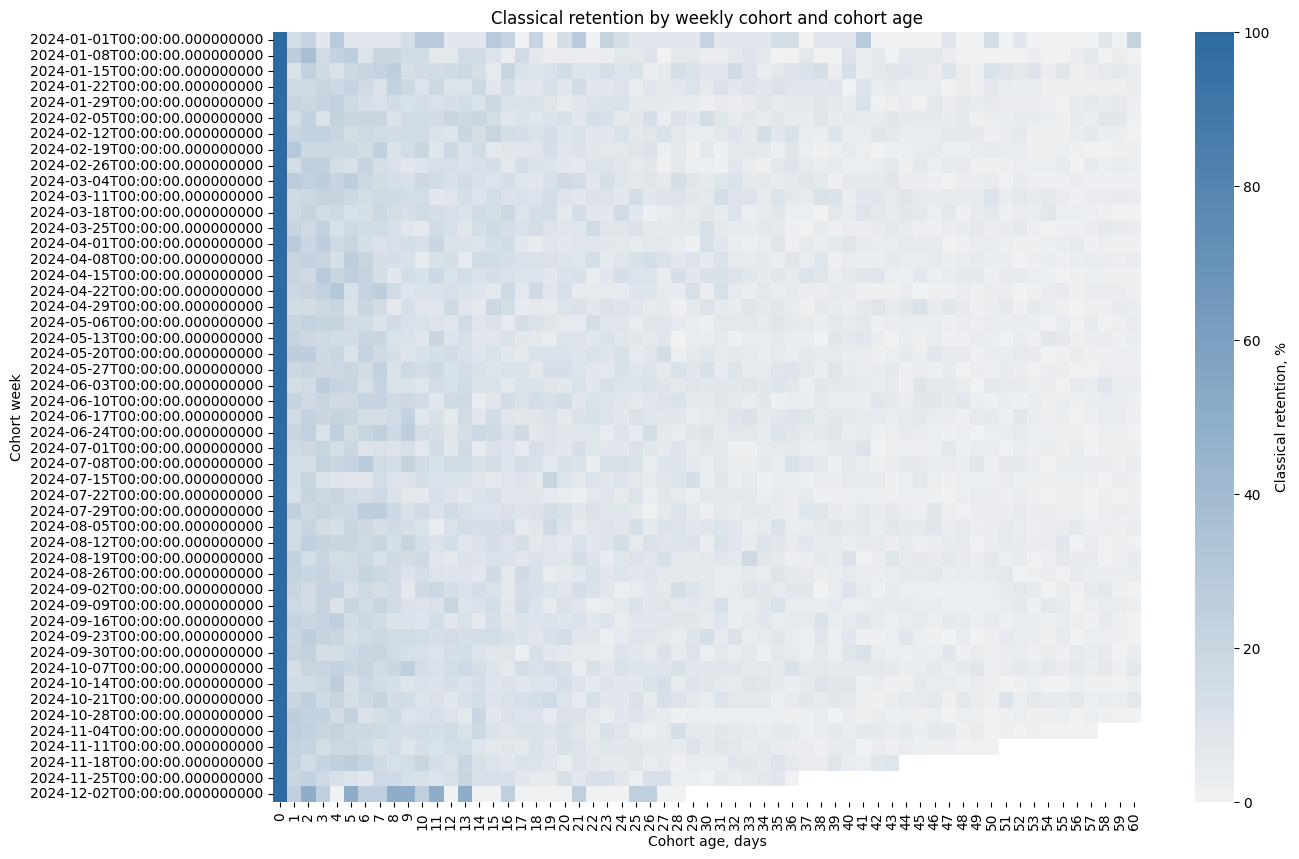

In [5]:
heatmap = classical.pivot(index='cohort_week', columns='cohort_age', values='retention')
plt.figure(figsize=(14, 10))
sns.heatmap(heatmap * 100, cmap=sns.light_palette('#2D6A9F', as_cmap=True), vmin=0, cbar_kws={'label': 'Classical retention, %'})
plt.title('Classical retention by weekly cohort and cohort age')
plt.xlabel('Cohort age, days')
plt.ylabel('Cohort week')
plt.show()

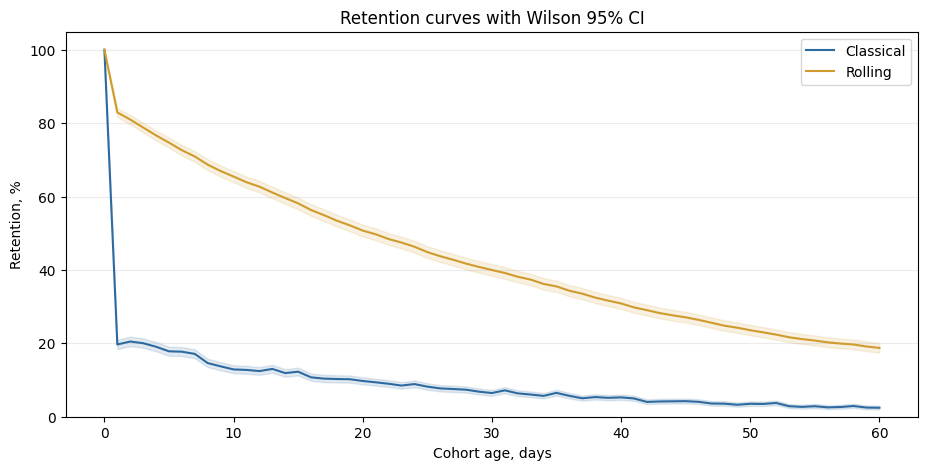

In [6]:
# Aggregate eligible numerators/denominators before computing curves and Wilson CIs.
def curve(frame, label):
    result = frame.groupby('cohort_age', as_index=False)[['eligible_users', 'retained_users']].sum()
    result[label] = result['retained_users'] / result['eligible_users']
    result['ci_low'], result['ci_high'] = wilson_interval(result['retained_users'], result['eligible_users'])
    return result

classic_curve = curve(classical, 'classical')
rolling_curve = curve(rolling, 'rolling')
fig, ax = plt.subplots(figsize=(11, 5))
for frame, column, color, label in [(classic_curve, 'classical', '#2D6A9F', 'Classical'), (rolling_curve, 'rolling', '#D09B2C', 'Rolling')]:
    ax.plot(frame['cohort_age'], frame[column] * 100, color=color, label=label)
    ax.fill_between(frame['cohort_age'], frame['ci_low'] * 100, frame['ci_high'] * 100, color=color, alpha=.14)
ax.set(title='Retention curves with Wilson 95% CI', xlabel='Cohort age, days', ylabel='Retention, %')
ax.set_ylim(bottom=0); ax.legend(); ax.grid(axis='y', alpha=.25)
plt.show()

### 4. Segmentation: first week and first-attempt experience

In [7]:
outcomes = early_outcomes(rides, users, data_end)
early_segment = retention_by_segment(outcomes, 'early_activity_segment')
first_attempt_segment = retention_by_segment(outcomes, 'first_attempt_status')
early_segment, first_attempt_segment

(  early_activity_segment  retained_users  eligible_users  retention    ci_low  \
 0                      0              34            1233   0.027575  0.019799   
 1                      1              50            1030   0.048544  0.037014   
 2                    2–3              97            1093   0.088747  0.073296   
 3                     4+              58             349   0.166189  0.130812   
 
     ci_high  
 0  0.038286  
 1  0.063429  
 2  0.107078  
 3  0.208835  ,
   first_attempt_status  retained_users  eligible_users  retention    ci_low  \
 0            cancelled               9             231   0.038961  0.020630   
 1            completed             223            3360   0.066369  0.058438   
 2                error               7             114   0.061404  0.030059   
 
     ci_high  
 0  0.072375  
 1  0.075291  
 2  0.121344  )

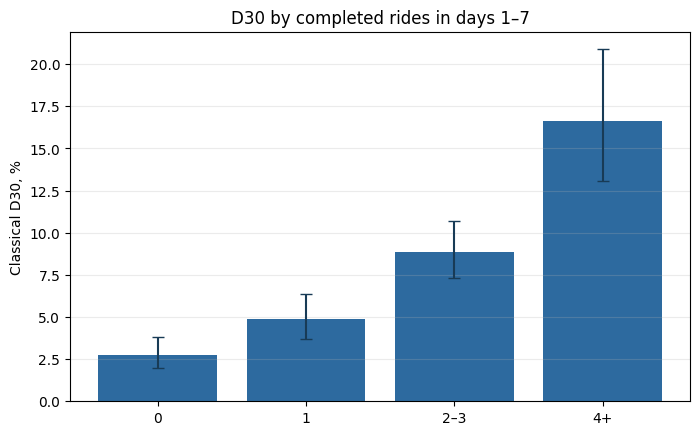

In [8]:
plot_data = early_segment.copy()
plot_data['early_activity_segment'] = pd.Categorical(plot_data['early_activity_segment'], ['0', '1', '2–3', '4+'], ordered=True)
plot_data = plot_data.sort_values('early_activity_segment')
x = np.arange(len(plot_data)); y = plot_data['retention'].to_numpy() * 100
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(x, y, color='#2D6A9F')
ax.errorbar(x, y, yerr=np.vstack([y - plot_data['ci_low'].to_numpy()*100, plot_data['ci_high'].to_numpy()*100 - y]), fmt='none', color='#183B56', capsize=4)
ax.set(xticks=x, xticklabels=plot_data['early_activity_segment'], ylabel='Classical D30, %', title='D30 by completed rides in days 1–7')
ax.grid(axis='y', alpha=.25)
plt.show()

### 5. Frequency and gaps with SQL window functions

In [9]:
intervals = run_sql_file(sqlite_path, ROOT / 'sql/ride_frequency_and_gaps.sql')
gaps = intervals.loc[intervals['gap_days'].notna(), 'gap_days']
print(f'Median gap: {gaps.median():.1f} days; P75: {gaps.quantile(.75):.1f} days')
intervals[['user_id', 'completed_ride_number', 'previous_completed_at', 'gap_days']].head(10)

Median gap: 2.9 days; P75: 6.2 days


,user_id,completed_ride_number,previous_completed_at,gap_days
0,U0000003,1,None,NaN
1,U0000003,2,2024-08-18 11:20:19.805896264+00:00,7.1195
2,U0000004,1,None,NaN
3,U0000006,1,None,NaN
4,U0000007,1,None,NaN
5,U0000007,2,2024-09-11 23:19:50.393100045+00:00,0.4874
6,U0000007,3,2024-09-12 11:01:40.193614565+00:00,0.2267
7,U0000008,1,None,NaN
8,U0000009,1,None,NaN
9,U0000009,2,2024-06-30 12:34:53.134477465+00:00,10.8117


## Takeaways

1. Повторная completed ride в первую неделю — сильный приоритизатор для CRM, но не доказательство того, что CRM создаст весь observed lift.
2. Первая ошибка/отмена требует отдельной воронки registration → first attempt → first completed ride; conditioning только на activated users создаёт selection bias.
3. Эксперимент нужно назначать на `user_id` до показа триггера и оценивать ITT на заранее заданном D30 с guardrails. Детали — в `docs/experiment_design.md`.